<h1>Visualizing and Comparing Sorting Algorithms</h1>
<h3>Computational Thinking with Python - <i>Final projet</i></h3>
<h5>Kolozsvári Barnabás</h5>

<h3><b>I. Introduction</b></h3>
<b>Why sorting is important</b>
<p>Sorting is a fundamental task in computer science and data processing. Whether you're organizing numbers, arranging names alphabetically, or preparing data for efficient searching, sorting algorithms play a key role.</p>
<b>The goal of the project</b>
<p>In this essay, we will compare sorting algorithms by implementing, expoloring their step-by-step execution, and measuring their performance across various input sizes. Through this, we’ll get a grasp of how different algorithmic strategies affect efficiency and scalability.</p>
<b>Algorithms implemented and tested:</b>
<ul>
    <li>Bubble sort</li>
    <li>Quick sort</li>
    <li>Shellsort</li>
    <li>Bogo sort</li>
</ul>

<h3><b>II. Decomposing the Problem</b></h3><p>At its core, the problem is simple: <i><b>given a list of numbers arrange them in an ascending (or descending) order.</b></i> To approach computionally, we will break it to smaller, managable sections:</p><ol><li>Introducing and implementing the algorithms</li><li>Generating various length inputs</li><li>Measuring runtimes</li> <li>Compating results</li><li>Drawing conclusions</li></ol>

<h3><b>III. The algorithms</b></h3>

<h4><b>a. Bubble Sort</b></h4>
<p>Bubble sort is a comparison sort which repeatedly steps through the input list element by element, comparing the current element with the one after it, swapping their values if needed. These passes through the list are repeated until no swaps have to be performed during a pass, meaning that the list has become fully sorted.</p>
<p>Bubble sort has a worst-case and average complexity of <b>O(<i>n</i><sup>2</sup>)</b>, where <i>n</i> is the number of items being sorted.</p>
<img src="https://www.w3schools.com/dsa/img_runtime_bubbleSort.png" alt="Bubble Sort runtime graph">

In [2]:
def BubbleSort(array):
    # length of the array
    n = len(array)

    # loop for the length of elements in the array
    for i in range(n-1):

        # loop from the "i"th element until the end of the array
        for j in range(n-i-1):

            # check if following element is bigger
            if array[j] > array[j+1]:

                # swap elements
                array[j], array[j+1] = array[j+1], array[j]

    return array

<h4><b>b. Quick Sort</b></h4>
<p>Quicksort is a divide-and-conquer algorithm. It works by selecting a "pivot" element from the array and partitioning the other elements into two sub-arrays, according to whether they are less than or greater than the pivot. The sub-arrays are then sorted recursively. (Recursion is when a function calls itself.)</p>
<p>On average, the algorithm takes <b>O(n log<sub>n</sub>)</b> comparisons to sort <i>n</i> items. <br>
In the worst case, it makes <b>O(n<sup>2</sup>)</b> comparisons.</p>
<img src="https://www.w3schools.com/dsa/img_runtime_quicksort.png" alt="Quick Sort runtime graph">

In [3]:
def Partition(array, low, high):
    # set value of pivot to the last element in subarray
    pivot = array[high]

    # index for elements of subarray smaller than or equal to the pivot 
    i = low - 1

    for j in range(low, high):
        # step boundary and switch elements if the current element is smaller than the pivot 
        if array[j] <= pivot:
            i += 1
            array[i], array[j] = array[j], array[i]

    # place the pivot right after the last smaller element
    array[i+1], array[high] = array[high], array[i+1]

    # return position of the pivot
    return i+1

def QuickSort(array, low=0, high=None):
    # set high to the index of the last element of array if none set
    if high is None:
        high = len(array) - 1

    # continue sorting if the subarray has more than one element
    if low < high:
        # partition the array and get the index of the pivot element
        pivot_index = Partition(array, low, high)

        # function call for LEFT of the pivot
        QuickSort(array, low, pivot_index-1)

        # function call for RIGHT of the pivot
        QuickSort(array, pivot_index+1, high)

    return array

<h4><b>d. Shellsort</b></h4>
<p>Shellsort is based on. The method starts by sorting pairs of elements far apart from each other, then progressively reducing the gap between elements to be compared. By starting with far-apart elements, it can move some out-of-place elements into the position faster than a simple nearest-neighbor exchange. The running time of Shellsort is heavily dependent on the gap sequence it uses. For many practical variants, determining their time complexity remains an open problem.</p>
<p><i>(The algorithm was first published by Donald Shell in 1959, and has nothing to do with shells.)</i></p>
<p>The worst-case complexity for shell sort is <b>O(n<sup>2</sup>)</b>. <br>
The average case complexity is <b>O(n log<sub>n</sub>)</b> ~ <b>O(n<sup>1.25</sup>)</b></p>
<img src="https://miro.medium.com/v2/resize:fit:1200/format:webp/1*-3XxtkR5fVhO11QSeqSV6w.jpeg" alt="Shell Sort runtime graph">

In [4]:
def ShellSort(array):
    # set the gap half the array length
    n = len(array)
    gap = int(n/2)

    # repeat until the entire array is gap sorted
    while gap > 0:

        for i in range(gap, n):
            # save array[i] in temp and make a hole at position i
            temp = array[i]

            # shift earlier gap-sorted elements up until the correct location for array[i] is found
            j = i
            while j >= gap and array[j-gap] >temp:
                array[j] = array[j-gap]
                j -= gap

            # put the temp (array[i]) in its correct location
            array[j] = temp

        # halve the gap    
        gap = int(gap/2)

    return array

<h4><b>e. Bogo Sort</b></h4>
<p>Bogosort <i>(also known as permutation sort and stupid sort)</i> is a sorting algorithm based on the generate and test paradigm. The function successively generates permutations of its input until it finds one that is sorted. </p>
<p>On average, the algorithm takes <b>O(n × n!)</b> comparisons to sort.<br>
Worst case however, it could take bogo sort <b>O(∞)</b>, which theoretically means that no matter how random it is, the array will not be sorted. Ever.</p>

In [5]:
import random

def BogoSort(array):
    while (is_sorted(array) == False):
        Shuffle(array)
    
    return array

# check if the array is sorted
def is_sorted(array):
    n = len(array)
    for i in range(0, n-1):
        if (array[i] > array[i+1]):
            return False
    return True

# creates a random permutaion of the array 
def Shuffle(array):
    n = len(array)
    for i in range(0, n):
        r = random.randint(0, n-1)
        array[i], array[r] = array[r], array[i]

<h3><b>IV. Generating input data and graphing runtimes</b></h3>
<p>Arrays with the count of <i><b>n</b></i> elements from the range <i><b>[0; 2n]</b></i> are created, then sorted while measuring the time until completion.</p>
<p><b>Data lengths:</b></p>
<ul>
    <li>500</li>
    <li>1000</li>
    <li>2500</li>
    <li>5000</li>
    <li>10000</li>
    <li>15000</li>
    <li>20000</li>
</ul>
<p><i>Bogo Sort is not measured and graphed in this instance.</i></p>

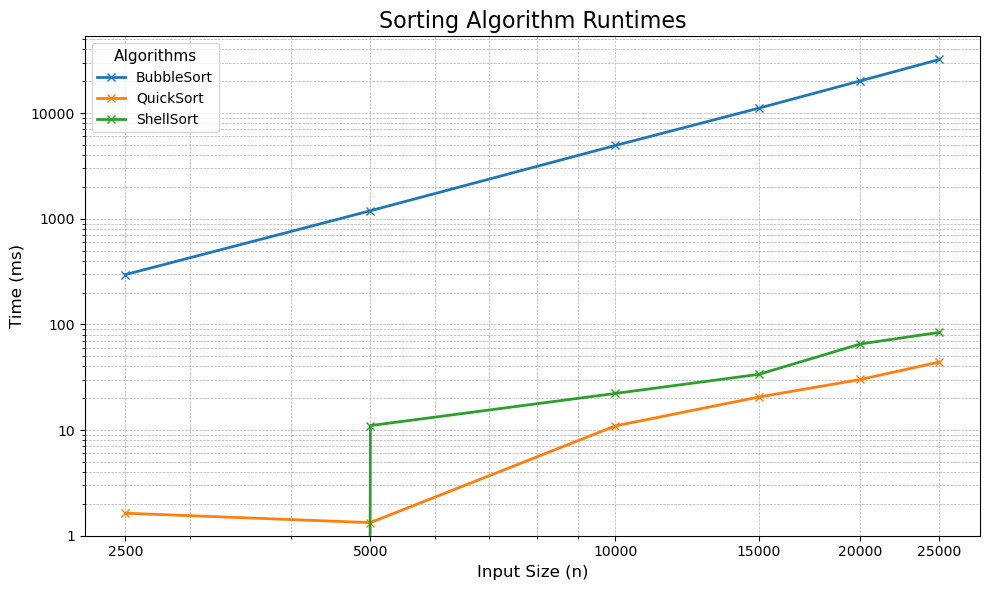

In [ ]:
#expected runtime for this complete code: ~1m 10s

import random
import time
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


def measure_sorting_algorithms():
    sizes = [2500, 5000, 10000, 15000, 20000, 25000]
    algorithms = {
        "BubbleSort": BubbleSort,
        "QuickSort": QuickSort,
        "ShellSort": ShellSort,
    }

    runtimes = {name: [] for name in algorithms.keys()}

    for size in sizes:
        base_array = random.sample(range(size * 2), size)

        for name, sort_func in algorithms.items():

            array = base_array.copy()

            start_time = time.time()
            _ = sort_func(array)
            end_time = time.time()

            elapsed_ms = (end_time - start_time) * 1000
            runtimes[name].append(elapsed_ms)

    return sizes, runtimes

def plot_runtimes(sizes, runtimes):
    plt.figure(figsize=(10, 6))

    for name, times in runtimes.items():
        times = [t if t is not None else float('nan') for t in times]
        plt.plot(sizes, times, label=name, marker='x', linewidth=2)

    plt.title("Sorting Algorithm Runtimes", fontsize=16)
    plt.xlabel("Input Size (n)", fontsize=12)
    plt.ylabel("Time (ms)", fontsize=12)
    plt.xscale("log")
    plt.yscale("log")

    plt.ylim(bottom=1) 

    ax = plt.gca()
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_major_formatter(ScalarFormatter())

    plt.xticks(sizes, labels=[str(s) for s in sizes])

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend(title="Algorithms", fontsize=10, title_fontsize=11)
    plt.tight_layout()
    plt.show()

sizes, runtimes = measure_sorting_algorithms()
plot_runtimes(sizes, runtimes)


<img src="graph_1.png">
<img src="graph_2.png">
<img src="graph_3.png">

<h3><b>V. Conclusion</b></h3>
<ul>
    <li>
    <b><i>Bubble Sort</i></b> exhibits the worst performance by far, with runtime growing rapidly as input size increases. Its steep upward curve on the log-log scale reflects its O(n²) time complexity, making it unsuitable for large datasets.
    </li>
    <br>
    <li>
    <b><i>Shell Sort</i></b> performs significantly better than Bubble Sort, benefiting from its gap-based comparisons. While its growth is not as steep, it still lags behind QuickSort at higher input sizes, suggesting a less efficient average-case behavior.
    </li>
    <br>
    <li>
    <b><i>QuickSort</i></b> consistently outperforms the others, maintaining the lowest runtime across all input sizes. Its nearly linear growth on the log scale illustrates its O(n log<sub>n</sub>) average-case efficiency, confirming it as <b><u>the most scalable and practical choice for larger inputs</u></b>.
    </li>
</ul>
<p>Overall, these graphs reinforces the importance of algorithm choice: even for the same task, performance differences can span several orders of magnitude, especially as input size grows. However, the simplicity of implementation is also to be considered when choosing an algorithm.</p>